# Case Study 2: Credit Card Fraud Detection using XGBoost & SMOTE
This notebook demonstrates a complete workflow to handle heavily imbalanced credit card transactions, apply SMOTE (Synthetic Minority Over-sampling Technique), train an XGBoost model, optimize the decision threshold, and interpret the feature importances.

In [1]:
# Install necessary libraries
!pip install -q imbalanced-learn xgboost

### 1. Download and Load Dataset
We will use the standard Kaggle **Credit Card Fraud Detection** dataset. Since accessing the Kaggle API directly requires credentials, we will provide a helper script to automatically download the dataset from a public mirror if it is not already present locally.

In [2]:
import pandas as pd
import numpy as np
import os
import urllib.request


url = "https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv"
csv_path = "creditcard.csv"

if not os.path.exists(csv_path):
    print("Downloading creditcard.csv...")
    urllib.request.urlretrieve(url, csv_path)
    print("Download complete.")
else:
    print("Dataset already exists locally.")

df = pd.read_csv(csv_path)
display(df.head())


print("\nClass Distribution:")
print(df['Class'].value_counts())
print(f"Percentage of fraudulent transactions: {df['Class'].mean() * 100:.4f}%")

Download complete.


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0



Class Distribution:
Class
0    284315
1       492
Name: count, dtype: int64
Percentage of fraudulent transactions: 0.1727%


### 2. Train-Test Split & SMOTE (Oversampling)
To avoid data leakage, we first split our dataset into training and testing sets, then apply SMOTE **only** to our training set.

In [3]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler


X = df.drop(columns=['Class'])
y = df['Class']


scaler = StandardScaler()
X[['Time', 'Amount']] = scaler.fit_transform(X[['Time', 'Amount']])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f"Original training shape: {X_train.shape} with {y_train.sum()} frauds")
print(f"Resampled training shape: {X_train_res.shape} with {y_train_res.sum()} frauds")

Original training shape: (227845, 30) with 394 frauds
Resampled training shape: (454902, 30) with 227451 frauds


### 3. Model Training (XGBoost)
We train an XGBoost classifier on the SMOTE-balanced training dataset.

In [4]:
import xgboost as xgb


xgb_clf = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_clf.fit(X_train_res, y_train_res)

print("XGBoost model training completed.")

/usr/local/lib/python3.13/dist-packages/xgboost/training.py:200: UserWarning: [17:12:25] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost model training completed.


### 4. Evaluate Threshold Tuning
By default, classifiers predict positive instances at a threshold of 0.5. For fraud detection, we often want a lower threshold to catch more fraudulent cases (higher recall), even if it yields some false alarms (lower precision).

In [5]:
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve
import matplotlib.pyplot as plt

y_probs = xgb_clf.predict_proba(X_test)[:, 1]

thresholds = [0.1, 0.3, 0.5, 0.7, 0.9]

for th in thresholds:
    y_pred_th = (y_probs >= th).astype(int)
    print(f"\n--- Classification Report at Threshold: {th} ---")
    print(classification_report(y_test, y_pred_th))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred_th))


--- Classification Report at Threshold: 0.1 ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.46      0.88      0.60        98

    accuracy                           1.00     56962
   macro avg       0.73      0.94      0.80     56962
weighted avg       1.00      1.00      1.00     56962

Confusion Matrix:
[[56761   103]
 [   12    86]]

--- Classification Report at Threshold: 0.3 ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.60      0.87      0.71        98

    accuracy                           1.00     56962
   macro avg       0.80      0.93      0.85     56962
weighted avg       1.00      1.00      1.00     56962

Confusion Matrix:
[[56807    57]
 [   13    85]]

--- Classification Report at Threshold: 0.5 ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   

### 5. Interpret Results: Feature Importance
Let's plot which features were most influential to the XGBoost model.

/tmp/ipykernel_2472/1397247047.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')


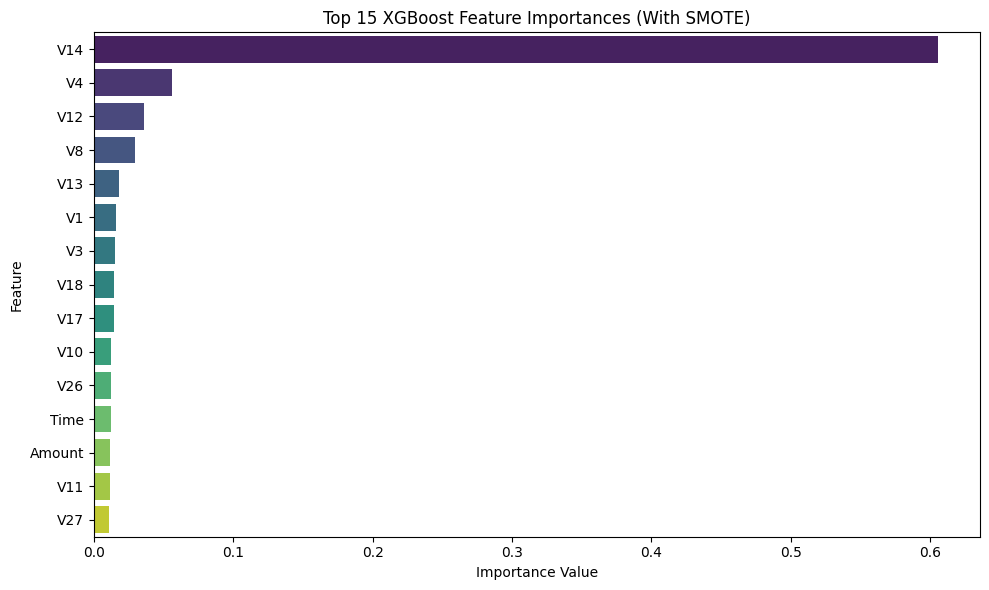

In [6]:
import seaborn as sns


importances = xgb_clf.feature_importances_
feature_names = X.columns


importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False).head(15)


plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title('Top 15 XGBoost Feature Importances (With SMOTE)')
plt.xlabel('Importance Value')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()